## MLP Classifier - Sentiment Analysis

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Load dataset

In [2]:
df = pd.read_csv("data/cleaned_imdb.csv")

### Minor cleaning

In [3]:
#drop empty rows
df = df[["clean_review", "sentiment"]].dropna()

#ensure sentiment is 0 or 1 int
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df[df["sentiment"].isin([0, 1])]
df["sentiment"] = df["sentiment"].astype(int)

#checking
print(df.shape)
print(df["sentiment"].value_counts())

(50000, 2)
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [4]:
#building feature matrix X and y
X = df["clean_review"].astype(str)
y = df["sentiment"]

### Splitting

In [6]:
#split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 35000 Test: 15000


### TF-IDF Vectorizer

In [7]:
#unigrams and bigrams are used to capture indiv words and short phrases
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(X_train_vec.shape, X_test_vec.shape)

(35000, 10000) (15000, 10000)


### Build MLP Classifier Model

In [8]:
configs = {
    "layer_1": (128,),
    "layer_2": (128, 64),
    "layer_3": (256, 128)
}

#### Tuning MLP Structures

In [9]:
best_name = None
best_layers = None
best_acc = -1

for name, layers in configs.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        max_iter=20,
        early_stopping=True,
        random_state=42
    )
    mlp.fit(X_train_vec, y_train)
    pred = mlp.predict(X_test_vec)
    acc = accuracy_score(y_test, pred)

    print(f"{name} {layers} | Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_layers = layers

print(f"\nBest MLP: {best_name} {best_layers} | Accuracy: {best_acc:.4f}")

layer_1 (128,) | Accuracy: 0.8964
layer_2 (128, 64) | Accuracy: 0.8918
layer_3 (256, 128) | Accuracy: 0.8921

Best MLP: layer_1 (128,) | Accuracy: 0.8964


### Training the final MLP Model

In [10]:
final_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=20,
    early_stopping=True,
    random_state=42
)

final_mlp.fit(X_train_vec, y_train)
y_pred_mlp = final_mlp.predict(X_test_vec)

### Evaluate final MLP

layer_1 Accuracy:  0.8964
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      7500
           1       0.89      0.90      0.90      7500

    accuracy                           0.90     15000
   macro avg       0.90      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000

Confusion matrix:
 [[6686  814]
 [ 740 6760]]


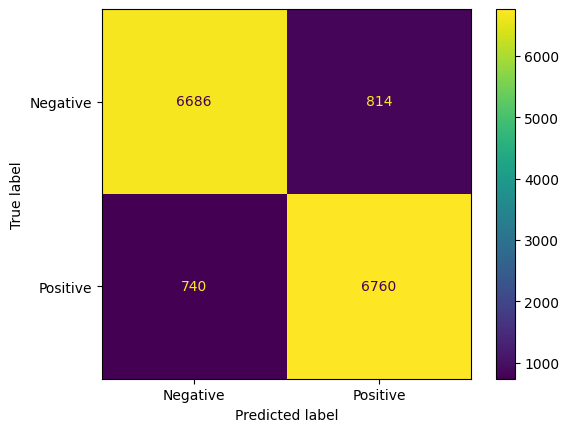

In [11]:
print(best_name, "Accuracy: ", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print("Confusion matrix:\n", cm_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=["Negative", "Positive"]
)
disp.plot(values_format="d")
plt.show()